# Case Técnico Turing USP 2026 — Parte 2: Análise de Dados e IA

**Objetivo:** investigar os fatores socioeconômicos e hábitos de estudo que impactam o desempenho acadêmico dos estudantes (`final_exam_score`) e construir modelos preditivos com Scikit-Learn.

O notebook está dividido em três partes, conforme o enunciado:
1. **Limpeza dos Dados** (10 pontos)
2. **Análise de Dados** (30 pontos)
3. **Modelos de Predição** (20 pontos)

## 0. Setup — Importações e Carregamento do Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
# 1. Carregamento do Dataset
url_dataset = "https://drive.google.com/uc?id=1_dPruQi9XN6JIbZ8sAwpGQDX6MZyIgeI"
df = pd.read_csv(url_dataset)

print("--- Formato do Dataset ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}\n")

print("--- Visão Geral dos Tipos e Nulos ---")
print(df.info())

print("\n--- Estatísticas Descritivas Iniciais ---")
df.describe()

--- Formato do Dataset ---
Linhas: 1020 | Colunas: 12

--- Visão Geral dos Tipos e Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1020 non-null   int64  
 1   gender                      1020 non-null   object 
 2   study_time_hours            969 non-null    float64
 3   attendance_percent          970 non-null    float64
 4   sleep_hours                 971 non-null    float64
 5   parental_education          917 non-null    object 
 6   internet_access             1020 non-null   object 
 7   extracurricular_activities  1020 non-null   object 
 8   part_time_job               1020 non-null   object 
 9   previous_grade              970 non-null    float64
 10  final_exam_score            967 non-null    float64
 11  final_grade                 1020 non-null   object 
dt

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1020.000000,969.000000,970.000000,971.000000,970.000000,967.000000
mean,502.918627,3.736533,84.843814,6.850360,69.599794,83.563599
std,288.735731,2.384867,11.983279,2.277942,12.634850,10.407444
min,1.000000,0.500000,-16.000000,-8.000000,31.300000,46.800000
25%,253.750000,2.600000,78.800000,5.900000,60.900000,76.050000
50%,505.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,752.250000,4.500000,91.900000,7.600000,78.375000,91.650000
max,1000.000000,29.000000,143.000000,35.000000,100.000000,100.000000


## 1. Limpeza dos Dados (10 pontos)

### Raciocínio das decisões de limpeza

1. **Remoção de identificadores:** a coluna `student_id` foi removida por ser apenas uma chave primária, sem valor preditivo.
2. **Correção de inconsistências físicas:** valores impossíveis (horas de sono/estudo negativas, presença fora de 0–100%, notas fora de 0–100) foram convertidos para `NaN` e depois imputados, em vez de simplesmente descartados — assim evitamos perder linhas inteiras por causa de uma única coluna inconsistente.
3. **Estratégia de imputação:** usamos a **mediana** para variáveis numéricas, por ser uma medida central pouco sensível a outliers, e a **moda** para variáveis categóricas, para preservar a distribuição original das categorias sem introduzir viés.
4. **Duplicatas exatas** foram removidas, já que representariam o mesmo aluno contado mais de uma vez.

In [ ]:
# Criando uma cópia para o processo de limpeza
df_clean = df.copy()

# 1. Remoção de duplicatas exatas e exclusão de IDs irrelevantes para os modelos
df_clean = df_clean.drop_duplicates()
if 'student_id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['student_id'])

# 2. Tratamento de Inconsistências Conhecidas (Regras de Domínio)
# a) Horas de estudo e sono não podem ser negativas
if 'study_time_hours' in df_clean.columns:
    df_clean.loc[df_clean['study_time_hours'] < 0, 'study_time_hours'] = np.nan

if 'sleep_hours' in df_clean.columns:
    df_clean.loc[df_clean['sleep_hours'] < 0, 'sleep_hours'] = np.nan

# b) Porcentagem de presença deve estar estritamente entre 0 e 100
if 'attendance_percent' in df_clean.columns:
    df_clean.loc[(df_clean['attendance_percent'] < 0) | (df_clean['attendance_percent'] > 100), 'attendance_percent'] = np.nan

# c) Notas anteriores e nota final devem estar dentro de limites plausíveis (0 a 100)
for col_nota in ['previous_grade', 'final_exam_score']:
    if col_nota in df_clean.columns:
        df_clean.loc[(df_clean[col_nota] < 0) | (df_clean[col_nota] > 100), col_nota] = np.nan

# 3. Tratamento de Valores Ausentes (Imputação Estratégica)
# Preenchimento de colunas numéricas com a mediana (mais robusta a outliers)
colunas_numericas = df_clean.select_dtypes(include=[np.number]).columns
for col in colunas_numericas:
    if df_clean[col].isna().sum() > 0:
        mediana = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mediana)

# Preenchimento de colunas categóricas com a moda (valor mais frequente)
colunas_categoricas = df_clean.select_dtypes(include=['object', 'category']).columns
for col in colunas_categoricas:
    if df_clean[col].isna().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda)

# 4. Verificação Final da Limpeza
print("--- Resumo de Nulos Pós-Limpeza ---")
print(df_clean.isna().sum())
print(f"\nDimensão final do dataset limpo: {df_clean.shape}")

--- Resumo de Nulos Pós-Limpeza ---
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

Dimensão final do dataset limpo: (1003, 11)


### Identificação de outliers

Além das inconsistências "físicas" (valores impossíveis), vale checar outliers *estatísticos* nas variáveis numéricas — valores que são plausíveis, mas muito distantes da maioria dos dados. Usamos boxplots e a regra do IQR (intervalo interquartil) só para *identificar*; não removemos automaticamente, porque em dados educacionais um outlier (ex: aluno que estuda 12h/dia) pode ser um caso real, não um erro.

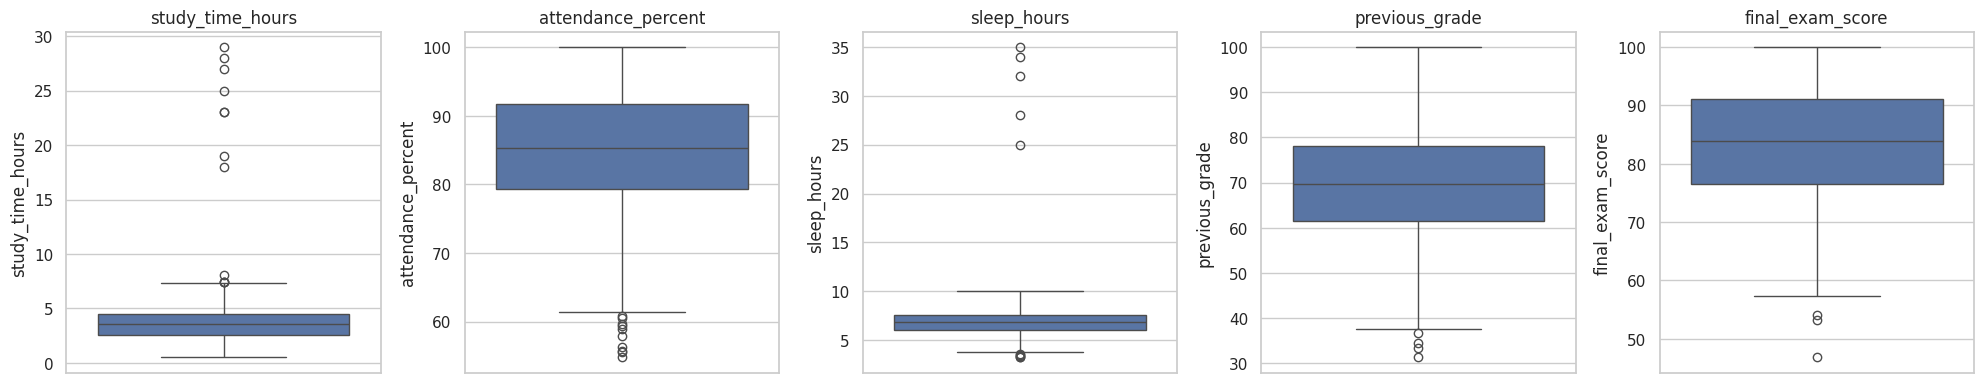

study_time_hours: 12 possíveis outliers (fora de [-0.2, 7.3])
attendance_percent: 10 possíveis outliers (fora de [61.0, 110.0])
sleep_hours: 10 possíveis outliers (fora de [3.6, 10.0])
previous_grade: 4 possíveis outliers (fora de [36.9, 102.7])
final_exam_score: 3 possíveis outliers (fora de [54.6, 113.0])


In [ ]:
num_cols = [c for c in ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score'] if c in df_clean.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Contagem de possíveis outliers pela regra do IQR, apenas para referência
for col in num_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)).sum()
    print(f"{col}: {n_outliers} possíveis outliers (fora de [{lim_inf:.1f}, {lim_sup:.1f}])")

**Insight:** *(ajuste este texto de acordo com o que os boxplots mostrarem quando você rodar com os dados reais)* — comente aqui se algum outlier chamou atenção e o que você decidiu fazer com eles (manter, pois são plausíveis, ou tratar como erro de registro).

## 2. Análise de Dados (30 pontos)

Objetivo: entender **quais fatores mais influenciam a nota final (`final_exam_score`)**. Vamos olhar as variáveis numéricas e categóricas, individualmente e em relação umas às outras, sempre com foco no alvo.

### 2.1 Distribuição da variável-alvo (`final_exam_score`)

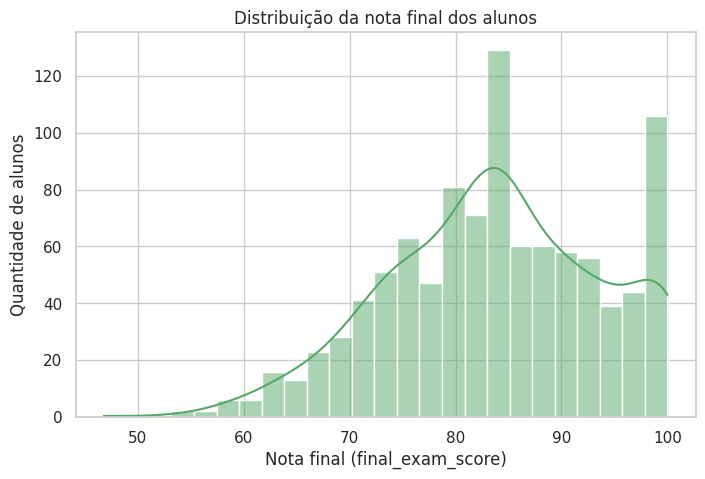

count    1003.000000
mean       83.667498
std        10.103874
min        46.800000
25%        76.500000
50%        83.900000
75%        91.100000
max       100.000000
Name: final_exam_score, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['final_exam_score'], kde=True, color="#55A868", bins=25)
plt.title("Distribuição da nota final dos alunos")
plt.xlabel("Nota final (final_exam_score)")
plt.ylabel("Quantidade de alunos")
plt.show()

print(df_clean['final_exam_score'].describe())

**Insight:** descreva aqui o formato da distribuição (simétrica? enviesada? bimodal?) e onde se concentra a maioria dos alunos.

### 2.2 Variáveis numéricas vs. nota final

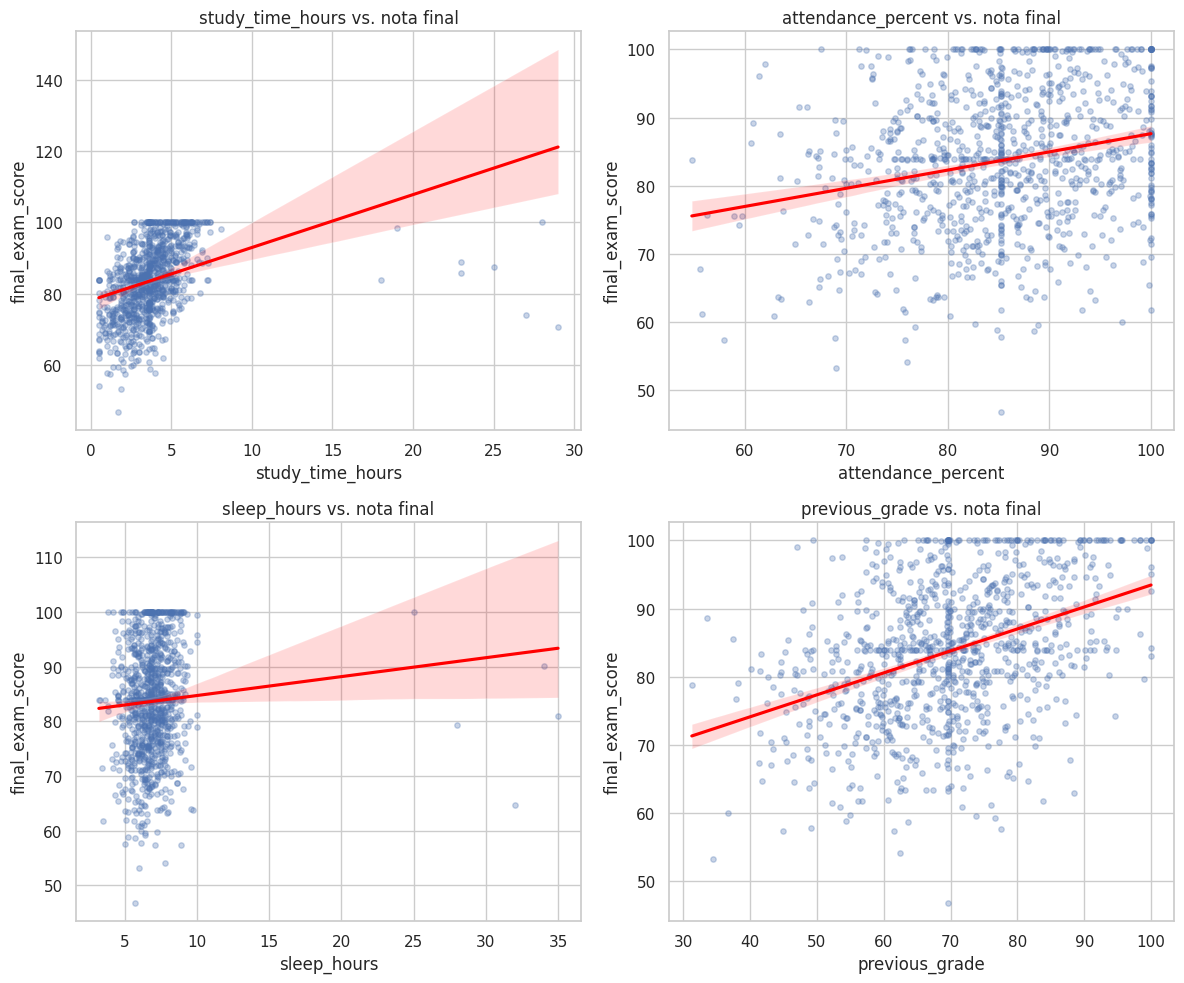

In [ ]:
num_features = [c for c in ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade'] if c in df_clean.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    sns.regplot(data=df_clean, x=col, y='final_exam_score', ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
    ax.set_title(f"{col} vs. nota final")
plt.tight_layout()
plt.show()

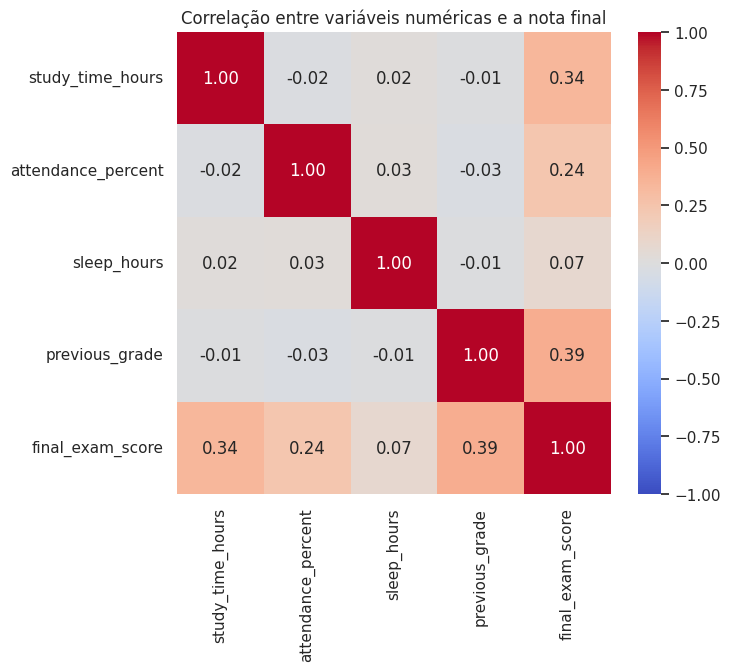

,final_exam_score
final_exam_score,1.000000
previous_grade,0.393171
study_time_hours,0.343697
attendance_percent,0.238594
sleep_hours,0.070746


In [ ]:
# Matriz de correlação entre as variáveis numéricas
corr_cols = num_features + ['final_exam_score']
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis numéricas e a nota final")
plt.show()

corr['final_exam_score'].sort_values(ascending=False)

**Insight:** aponte, com base na matriz de correlação, quais variáveis numéricas têm relação mais forte (positiva ou negativa) com `final_exam_score`, e comente se isso faz sentido intuitivamente (ex: mais horas de estudo → nota mais alta?).

### 2.3 Variáveis categóricas vs. nota final

/tmp/ipykernel_1974/4212626774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=col, y='final_exam_score', ax=ax, palette="Set2")
/tmp/ipykernel_1974/4212626774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=col, y='final_exam_score', ax=ax, palette="Set2")
/tmp/ipykernel_1974/4212626774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=col, y='final_exam_score', ax=ax, palette="Set2")
/tmp/ipykernel_1974/4212626774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` i

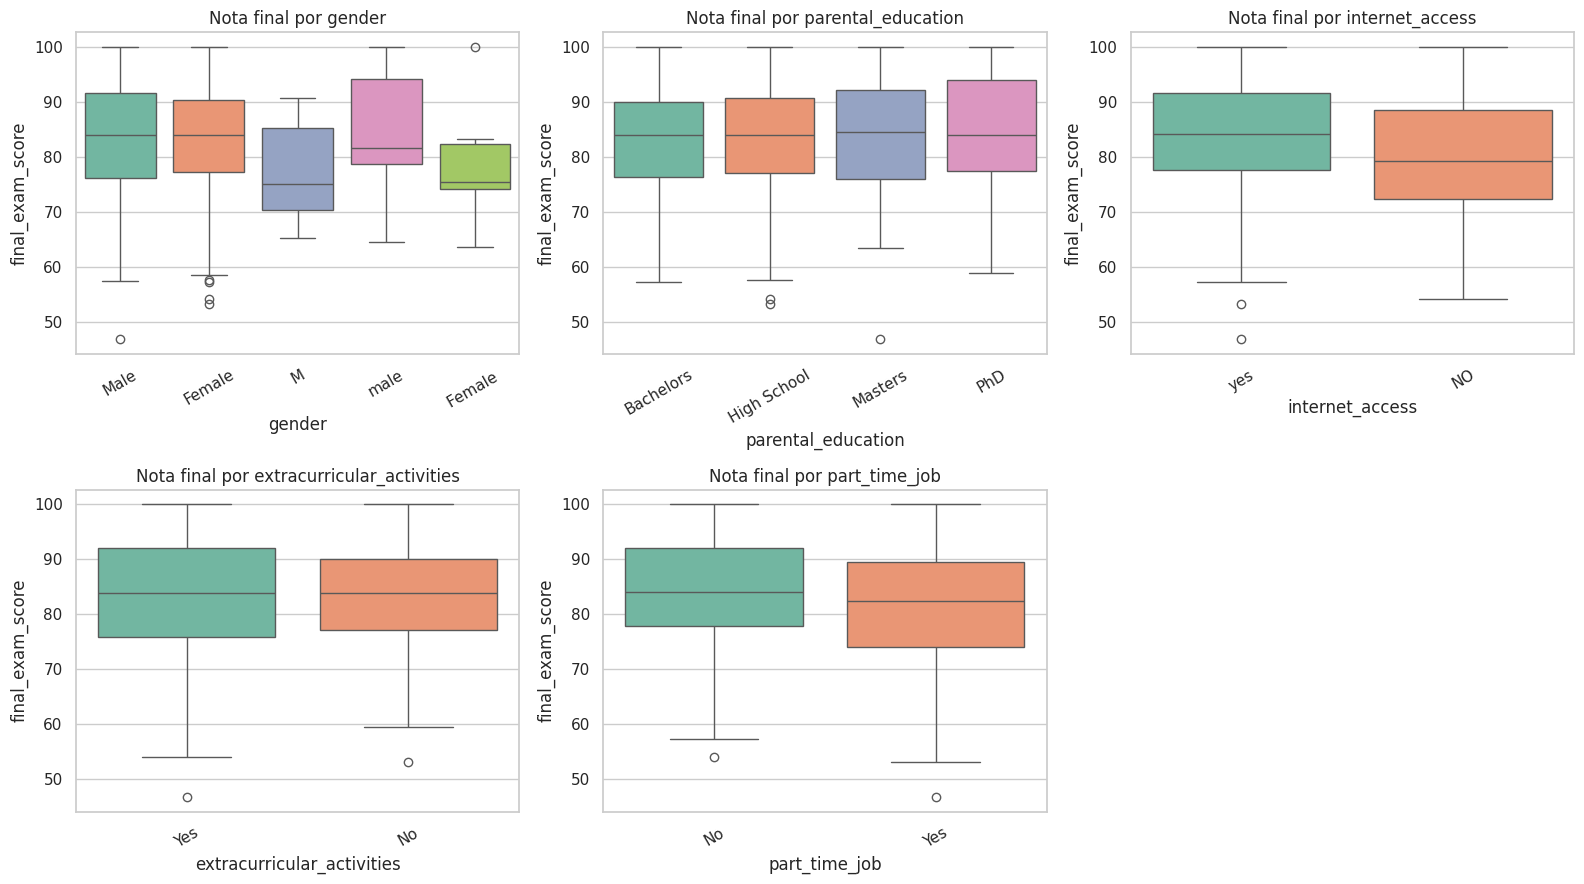

In [ ]:
cat_features = [c for c in ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job'] if c in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    sns.boxplot(data=df_clean, x=col, y='final_exam_score', ax=ax, palette="Set2")
    ax.set_title(f"Nota final por {col}")
    ax.tick_params(axis='x', rotation=30)
for ax in axes[len(cat_features):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Insight:** para cada variável categórica, comente se há diferença perceptível na mediana/dispersão da nota final entre os grupos (ex: alunos com acesso à internet tendem a ter nota mais alta?).

### 2.4 Cruzamento de múltiplas variáveis

Seguindo a sugestão do enunciado (gráfico de exemplo com escolaridade dos pais x horas de sono), vamos combinar 2–3 características para enriquecer a análise: horas de estudo (em faixas/quartis) x escolaridade dos pais, colorido pela nota final média.

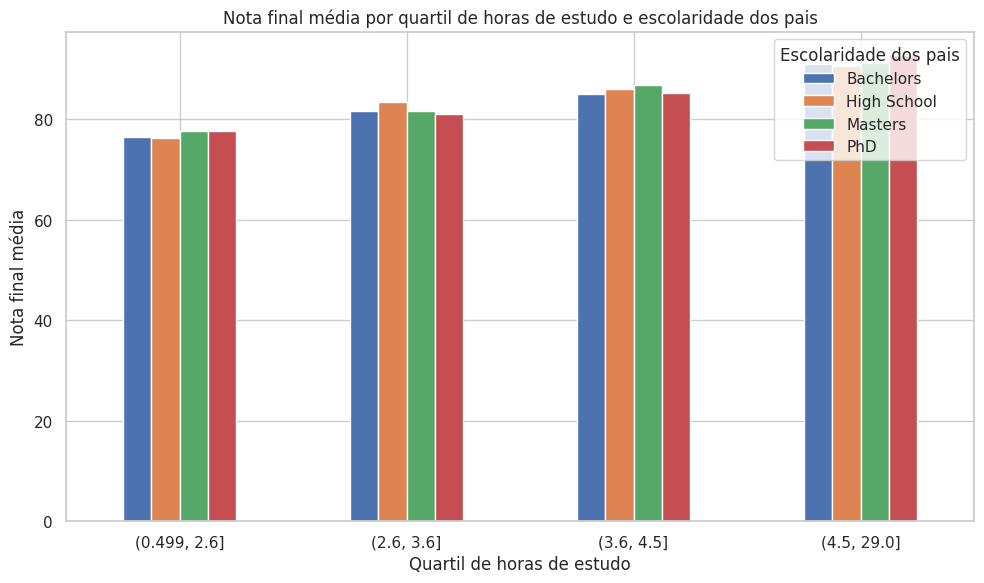

In [ ]:
if 'parental_education' in df_clean.columns and 'study_time_hours' in df_clean.columns:
    df_clean['study_time_quartil'] = pd.qcut(df_clean['study_time_hours'], 4, duplicates='drop')

    tabela_cruzada = df_clean.groupby(['study_time_quartil', 'parental_education'], observed=True)['final_exam_score'].mean().unstack()

    plt.figure(figsize=(10,6))
    tabela_cruzada.plot(kind='bar', ax=plt.gca())
    plt.title("Nota final média por quartil de horas de estudo e escolaridade dos pais")
    plt.xlabel("Quartil de horas de estudo")
    plt.ylabel("Nota final média")
    plt.xticks(rotation=0)
    plt.legend(title='Escolaridade dos pais')
    plt.tight_layout()
    plt.show()

**Insight:** comente se o efeito das horas de estudo na nota parece se manter constante entre os diferentes níveis de escolaridade dos pais, ou se há alguma interação interessante entre essas duas variáveis.

### 2.5 Conclusão da análise

*(preencha após rodar com os dados reais)* Resuma aqui, em 3–5 frases, quais foram os 2–3 fatores que mais parecem influenciar o desempenho dos alunos, juntando os pontos observados nas seções acima.

## 3. Modelos de Predição (20 pontos)

Vamos treinar **dois modelos** para prever `final_exam_score`: uma **Regressão Linear** (simples, interpretável, serve de baseline) e um **Random Forest Regressor** (captura relações não-lineares e interações entre variáveis). Depois comparamos os dois com métricas de erro.

### 3.1 Preparação dos dados (one-hot encoding + split treino/teste)

In [ ]:
from sklearn.model_selection import train_test_split

df_model = df_clean.drop(columns=[c for c in ['final_grade', 'study_time_quartil'] if c in df_clean.columns])

# One-hot encoding das variáveis categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=['final_exam_score'])
y = df_model['final_exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} alunos | Teste: {X_test.shape[0]} alunos | Features: {X.shape[1]}")

Treino: 802 alunos | Teste: 201 alunos | Features: 14


### 3.2 Modelo 1 — Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

### 3.3 Modelo 2 — Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

### 3.4 Avaliação e comparação dos modelos

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def avalia(y_true, y_pred, nome):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'Modelo': nome, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

resultados = pd.DataFrame([
    avalia(y_test, pred_lr, 'Regressão Linear'),
    avalia(y_test, pred_rf, 'Random Forest'),
]).set_index('Modelo')

resultados

,R2,RMSE,MAE
Modelo,,,
Regressão Linear,0.212843,8.743958,5.934646
Random Forest,0.568300,6.475426,5.251808


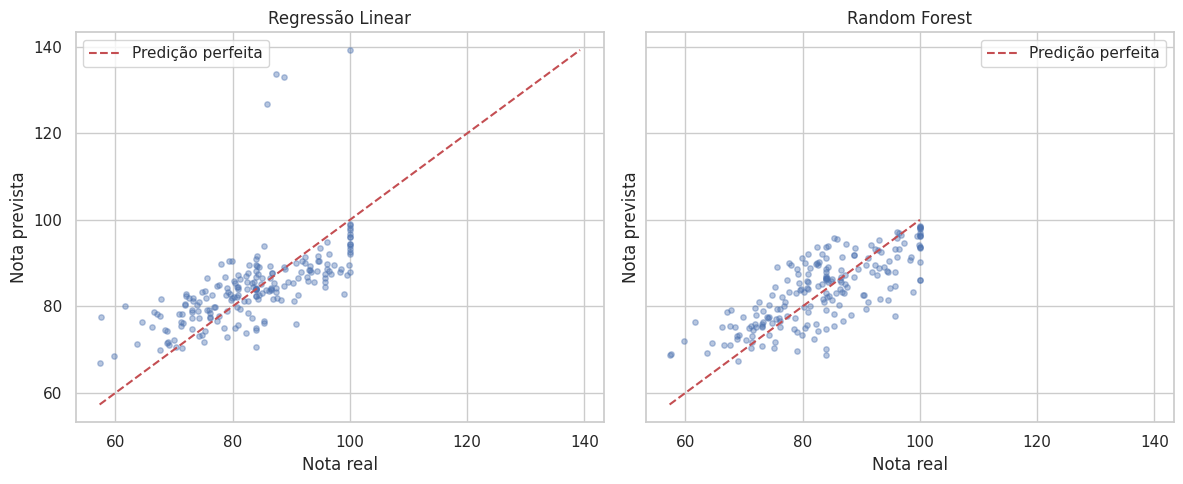

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
for ax, pred, nome in zip(axes, [pred_lr, pred_rf], ['Regressão Linear', 'Random Forest']):
    ax.scatter(y_test, pred, alpha=0.4, s=15)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='Predição perfeita')
    ax.set_xlabel('Nota real')
    ax.set_ylabel('Nota prevista')
    ax.set_title(nome)
    ax.legend()
plt.tight_layout()
plt.show()

**Comparação e conclusão:**

*(preencha após rodar com os dados reais)*

- Compare o **R²** dos dois modelos: qual explica mais da variância da nota final?
- Compare **RMSE** e **MAE**: qual modelo erra menos, em média, na previsão da nota?
- Se o Random Forest tiver desempenho bem melhor, isso sugere relações não-lineares entre as features e a nota; se forem parecidos, a relação é majoritariamente linear.
- Diga qual modelo você escolheria e por quê, considerando também interpretabilidade (a Regressão Linear permite olhar os coeficientes; o Random Forest permite olhar a importância das features — veja abaixo).

### 3.5 Importância das features (Random Forest)

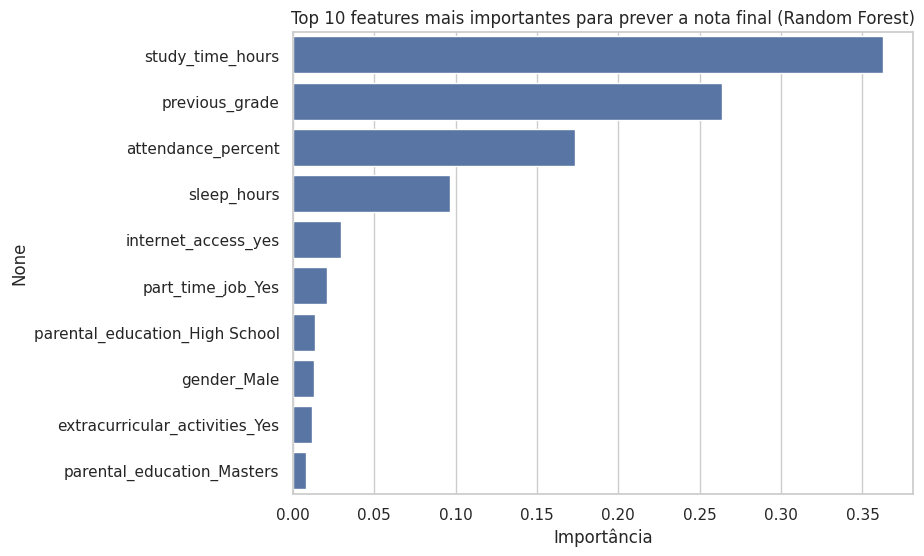

In [ ]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importancias.values, y=importancias.index, color="#4C72B0")
plt.title("Top 10 features mais importantes para prever a nota final (Random Forest)")
plt.xlabel("Importância")
plt.show()

**Insight:** as features mais importantes para o modelo batem com o que você encontrou na análise exploratória (seção 2)? Comente.

Com base na análise exploratória e na importância das features do modelo Random Forest, observa-se que:

- **Concordância com variáveis numéricas:** As variáveis numéricas mais importantes para o Random Forest (`study_time_hours`, `previous_grade`, `attendance_percent`, `sleep_hours`) seguem uma ordem de relevância similar àquela observada na matriz de correlação. `previous_grade` e `study_time_hours` mostraram as correlações mais fortes e também são as mais importantes para o modelo, o que é um achado consistente.
- **Diferenças sutis:** Embora `previous_grade` tenha a maior correlação linear, `study_time_hours` aparece como a feature mais importante no modelo Random Forest. Isso sugere que, para o Random Forest, `study_time_hours` pode ter interações não-lineares ou combinadas com outras variáveis que a tornam um preditor ligeiramente mais forte no contexto do modelo de árvore, mesmo que sua correlação linear pura seja um pouco menor.
- **Variáveis categóricas:** As variáveis categóricas como `internet_access`, `part_time_job`, `parental_education` e `gender` também contribuem para a previsão, embora com menor importância relativa comparada às numéricas principais. Isso alinha-se com a análise dos boxplots, onde algumas dessas categorias mostraram diferenças visuais nas medianas da nota final, indicando alguma influência.